In [49]:
#import libraries we will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
#loading the example data set
from sklearn.datasets import load_iris
data = load_iris()

In [51]:
desc_features = data.feature_names
print(desc_features)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [52]:
#set the data frame
df = pd.DataFrame(data.data , columns = data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [53]:
#importing the tree model we want to use
from sklearn.tree import DecisionTreeClassifier

In [54]:
#Creating an instance for the model
dt_clf = DecisionTreeClassifier(max_depth = 2, criterion = 'entropy', random_state = 0)

In [55]:
#Training data set
# Split the data first into training and testing datasets. We will use 2/3 of the data for training a model and
# the remaining 1/3 for understanding how well model fits.

# To do that, we will utilize train_test_split function from sklearn.model_selection.
# We will set the test_size=0.33. By default, this sampling is stratified.
# It returns a 4-tuple, where
# X_train and X_test are the descriptive features to be used for training and testing, respectively
# and Y_train and Y_test are the target variables for training and testing.

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df[desc_features], df['target'], test_size = 0.33, random_state = 0)

In [56]:
# to train the model, use 'fit' function. This will build a decision tree using training data.
dt_clf.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=0)

In [57]:
#Test the model on the data
y_pred = dt_clf.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 2, 1, 0, 1, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0, 1, 2, 2, 1, 2])

In [58]:
#checking for error in our predictions
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.9

In [59]:
#alternative 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
cm_df = pd.DataFrame(cm)
cm_df

,0,1,2
0,16,0,0
1,0,18,1
2,0,4,11


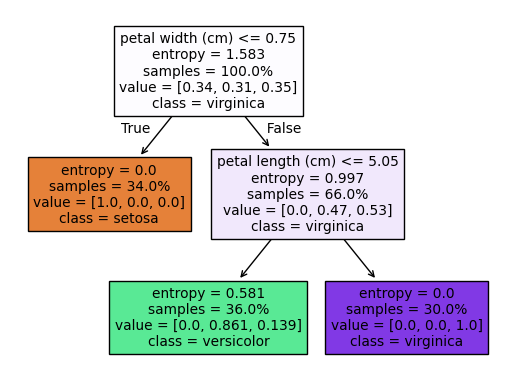

In [60]:
#Visualizing the tree
from sklearn import tree

ax=tree.plot_tree(dt_clf, feature_names = desc_features, class_names = data.target_names,
                  filled = True, proportion = True)

In [61]:
#Using decision trees for regression (continuous target features)
from sklearn.datasets import load_diabetes
lia_data = load_diabetes()
lia_desc_feat = lia_data.feature_names
lia_data.keys()
print(lia_desc_feat)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [62]:
lia_df = pd.DataFrame(lia_data.data, columns = lia_desc_feat)
lia_df['target'] = lia_data.target
lia_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [63]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth = 3, random_state = 0)
X_train, X_test, Y_train, Y_test = train_test_split(lia_df[lia_desc_feat], lia_df['target'], 
                                                    test_size = 0.25, random_state = 0)
dt_reg.fit(X_train, Y_train)
y_pred = dt_reg.predict(X_test)
y_pred

array([218.76190476, 222.75      , 218.76190476, 115.7628866 ,
       218.76190476, 265.76315789,  85.61428571, 265.76315789,
       146.94594595, 265.76315789, 163.575     , 146.94594595,
       115.7628866 , 115.7628866 , 222.75      , 115.7628866 ,
       115.7628866 ,  85.61428571, 115.7628866 , 218.76190476,
       218.76190476, 146.94594595, 163.575     , 146.94594595,
       222.75      , 222.75      ,  85.61428571,  85.61428571,
       163.575     , 146.94594595, 261.25      , 115.7628866 ,
       115.7628866 , 115.7628866 , 163.575     , 146.94594595,
       115.7628866 , 115.7628866 ,  85.61428571, 222.75      ,
       115.7628866 , 115.7628866 , 163.575     , 163.575     ,
       218.76190476,  85.61428571,  85.61428571, 146.94594595,
       115.7628866 , 222.75      , 115.7628866 , 115.7628866 ,
       218.76190476, 163.575     , 265.76315789, 261.25      ,
       222.75      ,  85.61428571, 115.7628866 , 163.575     ,
       265.76315789, 146.94594595, 146.94594595, 115.76

In [64]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, y_pred)

52.581299682030355

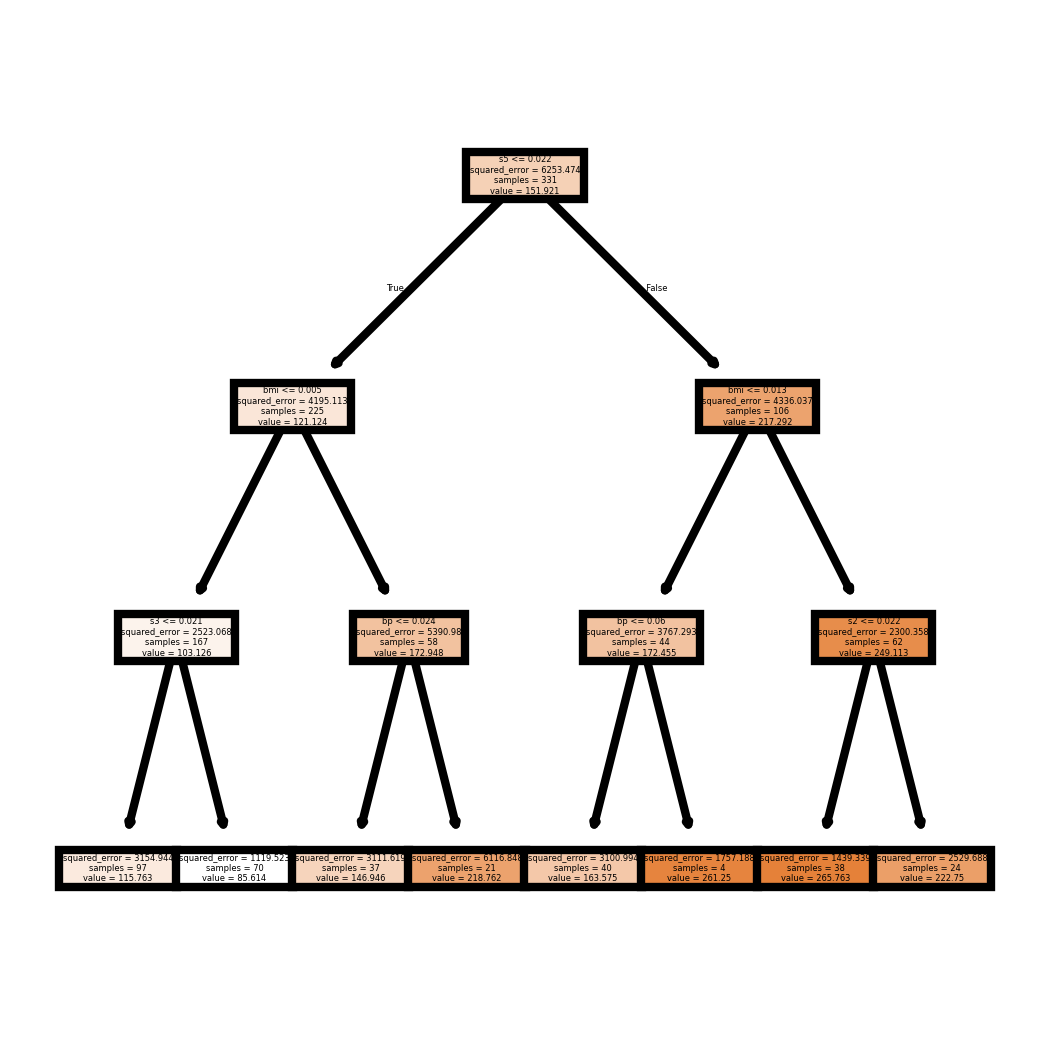

In [65]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (2,2), dpi = 600)
ax = tree.plot_tree(dt_reg, feature_names = lia_desc_feat, filled = True)

In [66]:
#Ensemble models 
data = load_iris()
desc_features = data.feature_names
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

X_train, X_test, Y_train, Y_test = train_test_split(df[desc_features], df['target'], 
                                                    test_size = 0.33, random_state = 0)


In [67]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(max_depth = 2, n_estimators = 4, random_state = 0)
rf_clf.fit(X_train, Y_train)
y_pred = rf_clf.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0, 1, 2, 2, 1, 2])

In [68]:
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.94

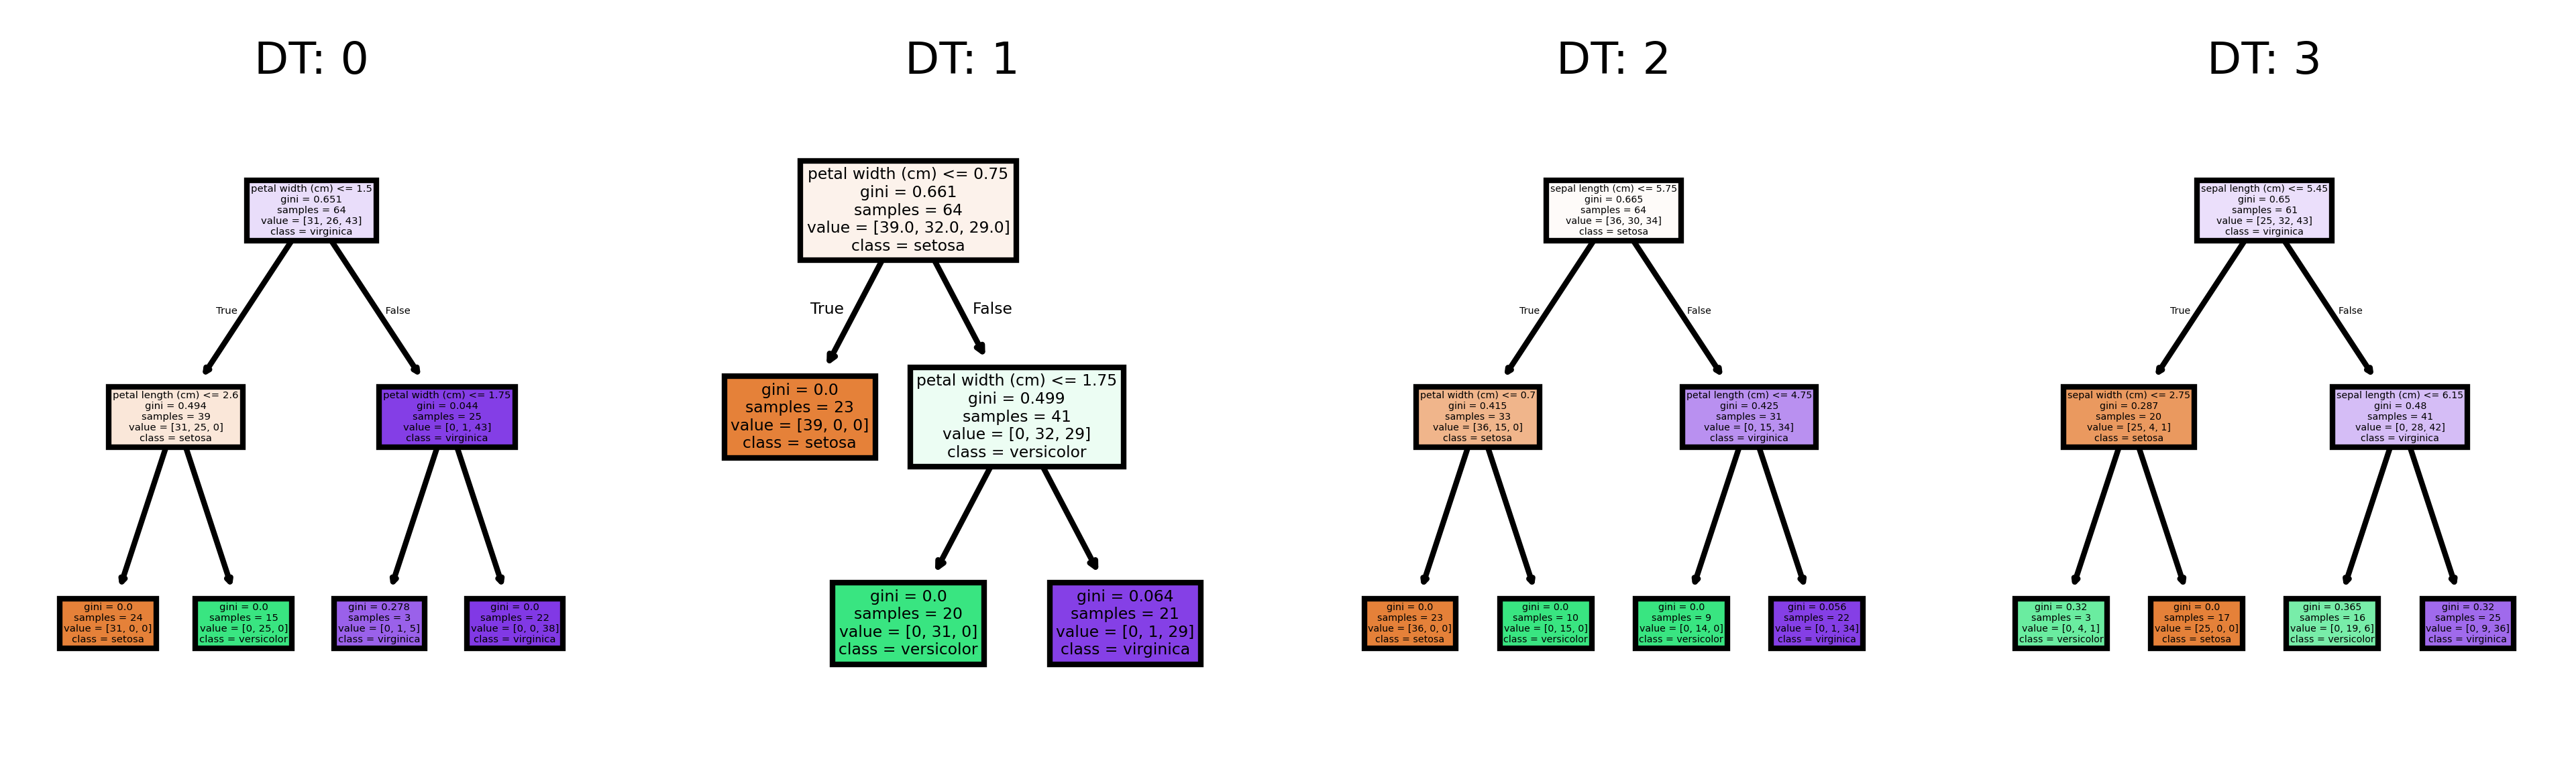

In [69]:
fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize = (8,2), dpi = 600)
for i in range(4):
    tree.plot_tree(rf_clf.estimators_[i],
                   feature_names = desc_features,
                   class_names = data.target_names, 
                   filled = True, 
                   ax = axes[i])
    axes[i].set_title('DT: ' + str(i), fontsize = 8)